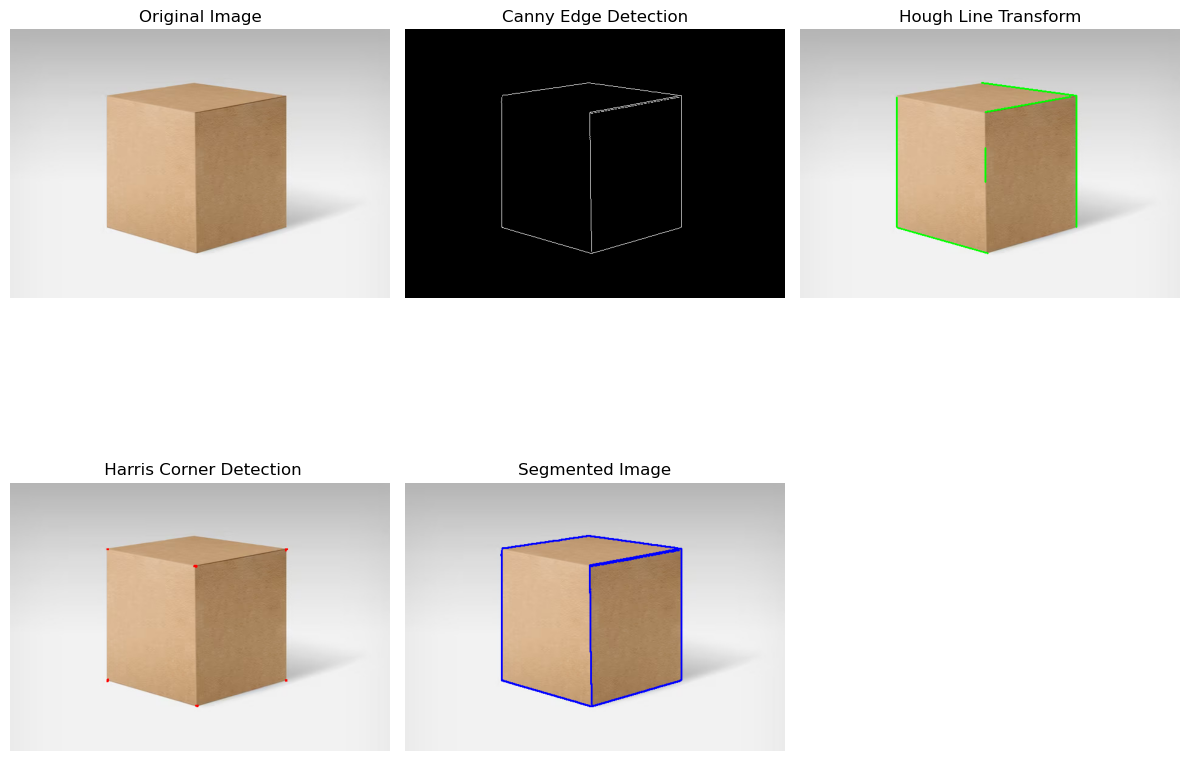

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('boxx.jpg')  # Replace with your image path
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Edge detection using Canny
edges = cv2.Canny(gray, 50, 150)

# Hough Line Transform
hough_image = image.copy()
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=100, minLineLength=50, maxLineGap=10)
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(hough_image, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Green lines

# Harris Corner Detection (Enhanced)
corner_image = image.copy()
gray_harris = np.float32(gray)
dst = cv2.cornerHarris(gray_harris, blockSize=2, ksize=3, k=0.04)

# Dilate corner markers for better visibility
dst = cv2.dilate(dst, None)
corner_image[dst > 0.01 * dst.max()] = [0, 0, 255]  # Mark corners in bright red

# Segmentation using contours
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
segmented_image = image.copy()
cv2.drawContours(segmented_image, contours, -1, (255, 0, 0), 2)  # Draw contours in blue

# Convert images to RGB for matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
hough_rgb = cv2.cvtColor(hough_image, cv2.COLOR_BGR2RGB)
corner_rgb = cv2.cvtColor(corner_image, cv2.COLOR_BGR2RGB)
segmented_rgb = cv2.cvtColor(segmented_image, cv2.COLOR_BGR2RGB)

# Plot images using subplots
plt.figure(figsize=(12, 10))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(hough_rgb)
plt.title("Hough Line Transform")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(corner_rgb)
plt.title(" Harris Corner Detection")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(segmented_rgb)
plt.title("Segmented Image")
plt.axis("off")

plt.tight_layout()
plt.show()
